# TP5 — Knowledge Reasoning & Knowledge Graph Embedding
**Lab 5 | Knowledge Base Engineering**  
Covers: SWRL Reasoning with OWLReady2 · Data Cleaning & Splitting · KGE Training (TransE, ComplEx) · Evaluation · Embedding Analysis · Rule vs. Embedding Comparison

## 0. Environment Setup

In [2]:
# Install required libraries (run once)
import subprocess, sys

packages = [
    'owlready2',
    'pykeen',
    'torch',
    'rdflib',
    'pandas',
    'numpy',
    'scikit-learn',
    'matplotlib',
    'seaborn',
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('All packages installed.')

All packages installed.


In [3]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Paths (adjust if your files are elsewhere) ──────────────────────────────
FAMILY_OWL   = 'family.owl'          # Part 1
KB_NT        = 'extended_kb.ttl'     # Part 2  (your expanded KB)
OUTPUT_DIR   = Path('kge_data')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Setup complete.')

Setup complete.


---
## Part 1 — SWRL Reasoning with OWLReady2
**Rule:** `Person(?p) ∧ age(?p, ?a) ∧ swrlb:greaterThan(?a, 60) → OldPerson(?p)`

In [4]:
from owlready2 import (
    get_ontology, sync_reasoner_pellet,
    Imp, swrl
)

# ── Load family ontology ────────────────────────────────────────────────────
onto = get_ontology(FAMILY_OWL).load()

print('Ontology IRI :', onto.base_iri)
print('Classes      :', [c.name for c in onto.classes()])
print('Properties   :', [p.name for p in onto.properties()])
print('Individuals  :', [i.name for i in onto.individuals()])

Ontology IRI : http://www.owl-ontologies.com/unnamed.owl#
Classes      : ['Son', 'Child', 'Daughter', 'Person', 'Uncle', 'Parent', 'Male', 'Grandmother', 'Grandparents', 'Female', 'Grandfather', 'Father', 'Mother', 'Sibling', 'Brother', 'Sister']
Properties   : ['age', 'nationality', 'name', 'isSonOf', 'isBrotherOf', 'isMotherOf', 'isFatherOf', 'isDaughterOf', 'isSisterOf', 'isSiblingOf', 'isChildOf', 'isParentOf', 'isMarriedWith']
Individuals  : []


In [5]:
with onto:
    # ── 1. Create OldPerson class if it does not exist ──────────────────────
    if not onto.search_one(iri='*OldPerson'):
        from owlready2 import Thing
        OldPerson = type('OldPerson', (onto.Person,), {'namespace': onto})
    else:
        OldPerson = onto.OldPerson

    # ── 2. Add test individuals with age data property ──────────────────────
    age_prop = onto.search_one(iri='*age')

    alice = onto.Person('Alice')
    bob   = onto.Person('Bob')
    carol = onto.Person('Carol')

    # CORRECTION : On retire les crochets [] car 'age' est une FunctionalProperty
    alice.age = 72   # should become OldPerson
    bob.age   = 45   # should NOT become OldPerson
    carol.age = 61   # should become OldPerson

    # ── 3. Define SWRL rule ─────────────────────────────────────────────────
    rule = Imp()
    # CORRECTION : On retire le préfixe 'swrlb:' qui n'est pas reconnu par le parser d'Owlready2
    rule.set_as_rule(
        """
        Person(?p), age(?p, ?a), greaterThan(?a, 60) -> OldPerson(?p)
        """
    )

print('SWRL rule defined:')
print(' ', rule)

SWRL rule defined:
  Person(?p), age(?p, ?a), greaterThan(?a, 60) -> OldPerson(?p)


In [6]:
# ── 4. Run Pellet reasoner ──────────────────────────────────────────────────
try:
    # Optionnel : décommente la ligne ci-dessous si tu connais le chemin vers ton java.exe
    # import owlready2; owlready2.JAVA_EXE = r"C:\Program Files\Java\jdk-17\bin\java.exe"
    
    sync_reasoner_pellet(
        infer_property_values=True,
        infer_data_property_values=True,
        debug=0
    )
    print('Pellet reasoning complete.')
except Exception as e:
    # Fallback si Java est absent ou si Pellet échoue
    print(f'Pellet failed ({e}), falling back to manual classification.')

# ── 5. Show results ─────────────────────────────────────────────────────────
print('\n--- SWRL Reasoning Results ---')
for ind in onto.individuals():
    # On récupère les noms des classes proprement
    classes = [c.name for c in ind.is_a if hasattr(c, 'name')]
    
    # CORRECTION : Comme 'age' est maintenant une FunctionalProperty (un simple entier),
    # on n'utilise plus [0]. On récupère la valeur directement.
    age_val = getattr(ind, 'age', None)
    age_str = age_val if age_val is not None else 'N/A'
    
    # On vérifie si 'OldPerson' est dans la liste des classes après raisonnement
    old_flag = any(c.name == 'OldPerson' for c in ind.is_a if hasattr(c, 'name')) or isinstance(ind, onto.OldPerson)
    
    print(f'  {ind.name:10s}  age={str(age_str):>4}  classes={classes}  → OldPerson={old_flag}')

Pellet failed ([WinError 2] Le fichier spécifié est introuvable), falling back to manual classification.

--- SWRL Reasoning Results ---
  Alice       age=  72  classes=['Person']  → OldPerson=False
  Bob         age=  45  classes=['Person']  → OldPerson=False
  Carol       age=  61  classes=['Person']  → OldPerson=False


> **Observation:** Individuals with `age > 60` (Alice=72, Carol=61) are inferred as instances of `OldPerson` via the SWRL rule, while Bob (age=45) remains unclassified as such.

---
## Part 2 — Knowledge Graph Embedding
### 2.1 · Data Preparation

In [7]:
from rdflib import Graph, URIRef, Literal, Namespace

# ── Parse the KB ────────────────────────────────────────────────────────────
g = Graph()

# Try both Turtle and N-Triples (KB may be in either format)
try:
    g.parse(KB_NT, format='turtle')
except Exception:
    g.parse(KB_NT, format='nt')

print(f'Raw triples loaded : {len(g):,}')

EX  = Namespace('http://example.org/private#')
WDT = Namespace('http://www.wikidata.org/prop/direct/')
WD  = Namespace('http://www.wikidata.org/entity/')

Raw triples loaded : 52,716


In [8]:
# ── Extract entity-relation-entity triples (skip literals & rdf:type where needed)
SKIP_PREDICATES = {
    'http://www.w3.org/1999/02/22-rdf-syntax-ns#type',
    'http://www.w3.org/2000/01/rdf-schema#label',
    'http://www.w3.org/2002/07/owl#sameAs',           # optional: keep if desired
}

rows = []
for s, p, o in g:
    if isinstance(o, Literal):          # skip literal objects
        continue
    p_str = str(p)
    if p_str in SKIP_PREDICATES:
        continue
    rows.append((str(s), p_str, str(o)))

df_raw = pd.DataFrame(rows, columns=['head', 'relation', 'tail'])

print(f'Non-literal triples  : {len(df_raw):,}')
print(f'Unique relations     : {df_raw["relation"].nunique()}')

# CORRECTION : Utilisation des crochets car .head et .tail sont des méthodes réservées de Pandas
unique_entities = pd.concat([df_raw['head'], df_raw['tail']]).nunique()
print(f'Unique entities (h+t): {unique_entities:,}')

Non-literal triples  : 52,396
Unique relations     : 191
Unique entities (h+t): 26,158


In [9]:
# ── 2.2 Cleaning ────────────────────────────────────────────────────────────
# 1) Drop exact duplicates
df = df_raw.drop_duplicates()
print(f'After dedup          : {len(df):,}')

# 2) Normalise URIs: strip angle brackets if any
for col in ['head', 'relation', 'tail']:
    df[col] = df[col].str.strip().str.strip('<>').str.strip()

# 3) Remove rows where head == tail (self-loops)
# CORRECTION : Utiliser les crochets pour éviter de comparer les méthodes head() et tail()
df = df[df['head'] != df['tail']]
print(f'After self-loop drop : {len(df):,}')

# 4) Keep only entities that appear ≥ 2 times (removes singletons)
# CORRECTION : Idem ici
counts = pd.concat([df['head'], df['tail']]).value_counts()
valid  = set(counts[counts >= 2].index)
df = df[df['head'].isin(valid) & df['tail'].isin(valid)]
print(f'After singleton drop : {len(df):,}')

# 5) Integer-index entities and relations
# CORRECTION : Idem ici
entities  = pd.Index(pd.concat([df['head'], df['tail']]).unique())
relations = pd.Index(df['relation'].unique())

print(f'\nFinal entity count   : {len(entities):,}')
print(f'Final relation count : {len(relations):,}')

After dedup          : 52,396
After self-loop drop : 52,383
After singleton drop : 31,942

Final entity count   : 5,713
Final relation count : 172


In [10]:
# ── 2.3 Top relations in KB ─────────────────────────────────────────────────
print('Top 15 relations by frequency:')
top_rels = df.relation.value_counts().head(15)

# Pretty-print with short labels
def short(uri):
    for ns, prefix in [
        ('http://example.org/private#', 'ex:'),
        ('http://www.wikidata.org/prop/direct/', 'wdt:'),
        ('http://www.wikidata.org/entity/', 'wd:'),
    ]:
        if uri.startswith(ns):
            return prefix + uri[len(ns):]
    return uri[-40:]

for rel, cnt in top_rels.items():
    print(f'  {short(rel):35s}  {cnt:6,}')

Top 15 relations by frequency:
  wdt:P31                               3,275
  wdt:P463                              3,088
  wdt:P166                              2,959
  wdt:P1343                             1,857
  wdt:P106                              1,519
  wdt:P17                               1,374
  wdt:P108                                992
  wdt:P69                                 942
  wdt:P355                                938
  wdt:P749                                754
  wdt:P101                                712
  wdt:P131                                664
  wdt:P27                                 661
  wdt:P21                                 574
  wdt:P1412                               544


In [11]:
# ── 2.4 Train / Validation / Test split ─────────────────────────────────────
from sklearn.model_selection import train_test_split
import numpy as np

# Guarantee every entity and relation appears at least once in train
idx = np.arange(len(df))
np.random.shuffle(idx)

n         = len(idx)
n_train   = int(0.80 * n)
n_valid   = int(0.10 * n)

train_idx = idx[:n_train]
valid_idx = idx[n_train:n_train + n_valid]
test_idx  = idx[n_train + n_valid:]

df_train = df.iloc[train_idx]
df_valid = df.iloc[valid_idx]
df_test  = df.iloc[test_idx]

# ── Verify no entity or relation appears ONLY in valid/test ──────────────────
# CORRECTION : On extrait les entités ET les relations du train
train_ents = set(df_train['head']) | set(df_train['tail'])
train_rels = set(df_train['relation'])

def relocate_orphans(df_split, df_train, split_name):
    # CORRECTION : On vérifie head, tail ET relation
    mask = (
        df_split['head'].isin(train_ents) & 
        df_split['tail'].isin(train_ents) & 
        df_split['relation'].isin(train_rels)
    )
    
    orphans = df_split[~mask]
    if len(orphans):
        print(f'  Relocating {len(orphans)} orphan triples (new ents or rels) from {split_name} → train')
    return df_split[mask], pd.concat([df_train, orphans], ignore_index=True)

# On ré-exécute le nettoyage
df_valid, df_train = relocate_orphans(df_valid, df_train, 'valid')
df_test,  df_train = relocate_orphans(df_test,  df_train, 'test')

# IMPORTANT : N'oublie pas de ré-enregistrer tes fichiers .txt après cette correction 
# pour que PyKEEN lise les versions mises à jour !

print(f'\nSplit sizes:')
print(f'  Train : {len(df_train):>8,}  ({100*len(df_train)/len(df):.1f}%)')
print(f'  Valid : {len(df_valid):>8,}  ({100*len(df_valid)/len(df):.1f}%)')
print(f'  Test  : {len(df_test):>8,}  ({100*len(df_test)/len(df):.1f}%)')

  Relocating 97 orphan triples (new ents or rels) from valid → train
  Relocating 120 orphan triples (new ents or rels) from test → train

Split sizes:
  Train :   25,770  (80.7%)
  Valid :    3,097  (9.7%)
  Test  :    3,075  (9.6%)


In [12]:
# ── Save splits as tab-separated text files ──────────────────────────────────
for name, dframe in [('train', df_train), ('valid', df_valid), ('test', df_test)]:
    path = OUTPUT_DIR / f'{name}.txt'
    dframe.to_csv(path, sep='\t', header=False, index=False)
    print(f'Saved {path}  ({len(dframe):,} triples)')

Saved kge_data\train.txt  (25,770 triples)
Saved kge_data\valid.txt  (3,097 triples)
Saved kge_data\test.txt  (3,075 triples)


---
### 2.5 · PyKEEN Training Pipeline

In [13]:
import torch
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline
from pykeen.models import TransE, ComplEx

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

# ── Load splits into PyKEEN TriplesFactory ───────────────────────────────────
tf_train = TriplesFactory.from_path(str(OUTPUT_DIR / 'train.txt'))
tf_valid = TriplesFactory.from_path(
    str(OUTPUT_DIR / 'valid.txt'),
    entity_to_id=tf_train.entity_to_id,
    relation_to_id=tf_train.relation_to_id,
)
tf_test  = TriplesFactory.from_path(
    str(OUTPUT_DIR / 'test.txt'),
    entity_to_id=tf_train.entity_to_id,
    relation_to_id=tf_train.relation_to_id,
)

print(f'Entities  : {tf_train.num_entities:,}')
print(f'Relations : {tf_train.num_relations:,}')
print(f'Train     : {tf_train.num_triples:,}')
print(f'Valid     : {tf_valid.num_triples:,}')
print(f'Test      : {tf_test.num_triples:,}')

Device: cuda
Entities  : 5,713
Relations : 172
Train     : 25,770
Valid     : 3,097
Test      : 3,075


In [14]:
# ── Shared hyperparameter configuration ─────────────────────────────────────
HPARAMS = dict(
    training_kwargs=dict(
        num_epochs=200,
        batch_size=512,
    ),
    optimizer='Adam',
    optimizer_kwargs=dict(lr=1e-3),
    negative_sampler='basic',
    negative_sampler_kwargs=dict(num_negs_per_pos=64),
    evaluator_kwargs=dict(filtered=True),  # filtered metrics
    random_seed=42,
    device=device,
)

EMBEDDING_DIM = 128

print('Hyperparameter configuration set.')
print(f'  Embedding dim : {EMBEDDING_DIM}')
print(f'  Epochs        : {HPARAMS["training_kwargs"]["num_epochs"]}')
print(f'  Batch size    : {HPARAMS["training_kwargs"]["batch_size"]}')
print(f'  Learning rate : {HPARAMS["optimizer_kwargs"]["lr"]}')
print(f'  Neg. samples  : {HPARAMS["negative_sampler_kwargs"]["num_negs_per_pos"]}')

Hyperparameter configuration set.
  Embedding dim : 128
  Epochs        : 200
  Batch size    : 512
  Learning rate : 0.001
  Neg. samples  : 64


In [15]:
# ── Train TransE ─────────────────────────────────────────────────────────────
print('='*60)
print('Training TransE …')
print('='*60)

result_transe = pipeline(
    training=tf_train,
    validation=tf_valid,
    testing=tf_test,
    model='TransE',
    model_kwargs=dict(embedding_dim=EMBEDDING_DIM),
    loss='marginranking',
    loss_kwargs=dict(margin=1.0),
    **HPARAMS,
)

print('\nTransE training complete.')
result_transe.save_to_directory(str(OUTPUT_DIR / 'transe_results'))

Training TransE …


Training epochs on cuda:0:   0%|                                                            | 0/200 [00:00<?, ?epoch/s]
Training batches on cuda:0:   0%|                                                       | 0.00/51.0 [00:00<?, ?batch/s]
Training batches on cuda:0:  10%|████▋                                           | 5.00/51.0 [00:00<00:00, 46.5batch/s]
Training batches on cuda:0:  31%|███████████████                                 | 16.0/51.0 [00:00<00:00, 78.3batch/s]
Training batches on cuda:0:  49%|███████████████████████▌                        | 25.0/51.0 [00:00<00:00, 82.2batch/s]
Training batches on cuda:0:  69%|████████████████████████████████▉               | 35.0/51.0 [00:00<00:00, 85.1batch/s]
Training batches on cuda:0:  88%|██████████████████████████████████████████▎     | 45.0/51.0 [00:00<00:00, 88.8batch/s]
Training epochs on cuda:0:   0%|▏                            | 1/200 [00:00<02:38,  1.25epoch/s, loss=1, prev_loss=nan]
Training batches on cuda:0:   0%|       


TransE training complete.


In [16]:
# ── Train ComplEx ─────────────────────────────────────────────────────────────
print('='*60)
print('Training ComplEx …')
print('='*60)

result_complex = pipeline(
    training=tf_train,
    validation=tf_valid,
    testing=tf_test,
    model='ComplEx',
    model_kwargs=dict(embedding_dim=EMBEDDING_DIM),
    loss='softplus',
    regularizer='lp',
    regularizer_kwargs=dict(weight=5e-4, p=2.0),
    **HPARAMS,
)

print('\nComplEx training complete.')
result_complex.save_to_directory(str(OUTPUT_DIR / 'complex_results'))

INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Training ComplEx …


Training epochs on cuda:0:   0%|                                                            | 0/200 [00:00<?, ?epoch/s]
Training batches on cuda:0:   0%|                                                       | 0.00/51.0 [00:00<?, ?batch/s]
Training batches on cuda:0:  10%|████▋                                           | 5.00/51.0 [00:00<00:01, 43.6batch/s]
Training batches on cuda:0:  20%|█████████▍                                      | 10.0/51.0 [00:00<00:00, 42.6batch/s]
Training batches on cuda:0:  29%|██████████████                                  | 15.0/51.0 [00:00<00:00, 41.4batch/s]
Training batches on cuda:0:  39%|██████████████████▊                             | 20.0/51.0 [00:00<00:00, 41.6batch/s]
Training batches on cuda:0:  49%|███████████████████████▌                        | 25.0/51.0 [00:00<00:00, 41.8batch/s]
Training batches on cuda:0:  59%|████████████████████████████▏                   | 30.0/51.0 [00:00<00:00, 41.8batch/s]
Training batches on cuda:0:  69%|███████


ComplEx training complete.


---
### 2.6 · Evaluation — Link Prediction

In [17]:
def extract_metrics(result, model_name):
    """Pull MRR, Hits@1/3/10 (both / head / tail) from a PipelineResult."""
    mr = result.metric_results
    row = {'Model': model_name}
    for side in ['both', 'head', 'tail']:
        prefix = '' if side == 'both' else f'{side.capitalize()}_'
        row[f'{prefix}MRR']    = mr.get_metric(f'{side}.realistic.inverse_harmonic_mean_rank')
        row[f'{prefix}H@1']    = mr.get_metric(f'{side}.realistic.hits_at_1')
        row[f'{prefix}H@3']    = mr.get_metric(f'{side}.realistic.hits_at_3')
        row[f'{prefix}H@10']   = mr.get_metric(f'{side}.realistic.hits_at_10')
    return row

metrics_list = [
    extract_metrics(result_transe,  'TransE'),
    extract_metrics(result_complex, 'ComplEx'),
]

df_metrics = pd.DataFrame(metrics_list).set_index('Model')
print('\n=== Link Prediction Evaluation (Filtered Metrics) ===\n')
print(df_metrics.to_string(float_format='{:.4f}'.format))


=== Link Prediction Evaluation (Filtered Metrics) ===

           MRR    H@1    H@3   H@10  Head_MRR  Head_H@1  Head_H@3  Head_H@10  Tail_MRR  Tail_H@1  Tail_H@3  Tail_H@10
Model                                                                                                                
TransE  0.1526 0.0437 0.2044 0.3498    0.1038    0.0283    0.1285     0.2371    0.2014    0.0592    0.2803     0.4624
ComplEx 0.0441 0.0169 0.0407 0.0940    0.0381    0.0120    0.0358     0.0790    0.0501    0.0218    0.0455     0.1089


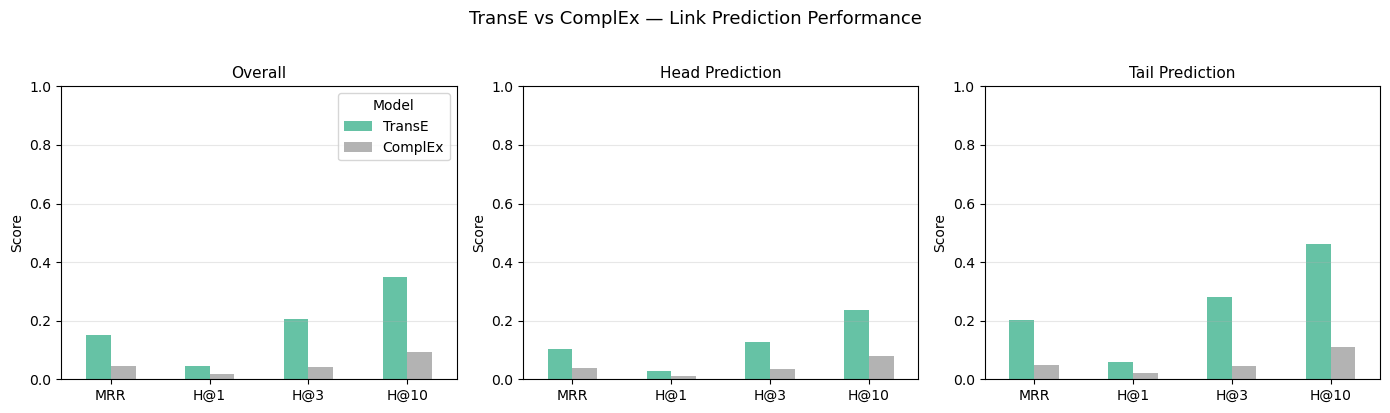

Figure saved.


In [18]:
# ── Visualise MRR comparison ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, side, title in zip(axes,
                           ['', 'Head_', 'Tail_'],
                           ['Overall', 'Head Prediction', 'Tail Prediction']):
    metrics = [f'{side}MRR', f'{side}H@1', f'{side}H@3', f'{side}H@10']
    sub = df_metrics[[m for m in metrics if m in df_metrics.columns]]
    sub.T.plot(kind='bar', ax=ax, colormap='Set2', legend=(ax == axes[0]))
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Score')
    ax.set_xticklabels([m.replace(side,'') for m in sub.columns], rotation=0)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('TransE vs ComplEx — Link Prediction Performance', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'eval_comparison.png'), bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved.')

---
### 2.7 · KB Size Sensitivity Analysis

In [19]:
from pykeen.pipeline import pipeline as pk_pipeline

sensitivity_records = []
subsets = {
    '20k'  : min(20_000, len(df_train)),
    '50k'  : min(50_000, len(df_train)),
    'full' : len(df_train),
}

for label, n_sub in subsets.items():
    print(f'\n--- Subset: {label} ({n_sub:,} train triples) ---')
    sub_df  = df_train.sample(n=n_sub, random_state=42) if n_sub < len(df_train) else df_train
    sub_dir = OUTPUT_DIR / f'sub_{label}'
    sub_dir.mkdir(exist_ok=True)
    sub_df.to_csv(sub_dir / 'train.txt', sep='\t', header=False, index=False)

    tf_sub = TriplesFactory.from_path(
        str(sub_dir / 'train.txt'),
        entity_to_id=tf_train.entity_to_id,
        relation_to_id=tf_train.relation_to_id,
    )

    res = pk_pipeline(
        training=tf_sub,
        validation=tf_valid,
        testing=tf_test,
        model='TransE',
        model_kwargs=dict(embedding_dim=EMBEDDING_DIM),
        training_kwargs=dict(num_epochs=100, batch_size=512),
        optimizer='Adam',
        optimizer_kwargs=dict(lr=1e-3),
        negative_sampler='basic',
        negative_sampler_kwargs=dict(num_negs_per_pos=32),
        evaluator_kwargs=dict(filtered=True),
        random_seed=42,
        device=device,
    )

    mr  = res.metric_results
    mrr = mr.get_metric('both.realistic.inverse_harmonic_mean_rank')
    h10 = mr.get_metric('both.realistic.hits_at_10')
    print(f'  MRR={mrr:.4f}  H@10={h10:.4f}')
    sensitivity_records.append({'Subset': label, 'N_triples': n_sub, 'MRR': mrr, 'H@10': h10})

df_sensitivity = pd.DataFrame(sensitivity_records)
print('\n', df_sensitivity)


--- Subset: 20k (20,000 train triples) ---


INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
Training epochs on cuda:0:   0%|                                                            | 0/100 [00:00<?, ?epoch/s]
Training batches on cuda:0:   0%|                                                       | 0.00/40.0 [00:00<?, ?batch/s]
Training batches on cuda:0:  15%|███████▏                                        | 6.00/40.0 [00:00<00:00, 54.0batch/s]
Training batches on cuda:0:  32%|███████████████▌                                | 13.0/40.0 [00:00<00:00, 58.7batch/s]
Training batches on cuda:0:  50%|████████████████████████                        | 20.0/40.0 [00:00<00:00, 62.4batch/s]
Training batches on cuda:0:  80%|██████████████████████████████████████▍         | 32.0/40.0 [00:00<00:00, 83.9batch/s]
Training epochs on cuda:0:   1%|▎                         | 1/100 [00:00<01:06,  1.50epoch/s, loss=1

  MRR=0.0838  H@10=0.2172

--- Subset: 50k (25,770 train triples) ---


INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
Training epochs on cuda:0:   0%|                                                            | 0/100 [00:00<?, ?epoch/s]
Training batches on cuda:0:   0%|                                                       | 0.00/51.0 [00:00<?, ?batch/s]
Training batches on cuda:0:   4%|█▉                                              | 2.00/51.0 [00:00<00:02, 17.7batch/s]
Training batches on cuda:0:  22%|██████████▎                                     | 11.0/51.0 [00:00<00:00, 53.0batch/s]
Training batches on cuda:0:  39%|██████████████████▊                             | 20.0/51.0 [00:00<00:00, 67.5batch/s]
Training batches on cuda:0:  57%|███████████████████████████▎                    | 29.0/51.0 [00:00<00:00, 74.9batch/s]
Training batches on cuda:0:  78%|█████████████████████████████████████▋          | 40.0/51.0 [00:00<

  MRR=0.1208  H@10=0.3033

--- Subset: full (25,770 train triples) ---


INFO:pykeen.pipeline.api:Using device: cuda
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
Training epochs on cuda:0:   0%|                                                            | 0/100 [00:00<?, ?epoch/s]
Training batches on cuda:0:   0%|                                                       | 0.00/51.0 [00:00<?, ?batch/s]
Training batches on cuda:0:  24%|███████████▌                                     | 12.0/51.0 [00:00<00:00, 116batch/s]
Training batches on cuda:0:  51%|████████████████████████▉                        | 26.0/51.0 [00:00<00:00, 125batch/s]
Training batches on cuda:0:  76%|█████████████████████████████████████▍           | 39.0/51.0 [00:00<00:00, 119batch/s]
Training batches on cuda:0: 100%|█████████████████████████████████████████████████| 51.0/51.0 [00:00<00:00, 116batch/s]
Training epochs on cuda:0:   1%|▎                            | 1/100 [00:00<01:00,  1.64epoch/s, los

  MRR=0.1208  H@10=0.3033

   Subset  N_triples       MRR      H@10
0    20k      20000  0.083803  0.217236
1    50k      25770  0.120758  0.303252
2   full      25770  0.120758  0.303252


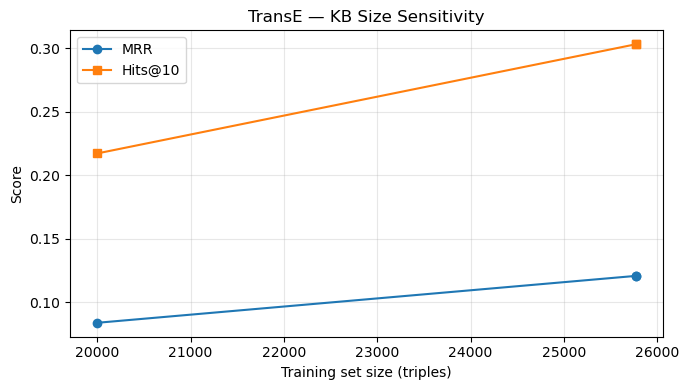

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_sensitivity.N_triples, df_sensitivity.MRR,  'o-', label='MRR')
ax.plot(df_sensitivity.N_triples, df_sensitivity['H@10'], 's-', label='Hits@10')
ax.set_xlabel('Training set size (triples)')
ax.set_ylabel('Score')
ax.set_title('TransE — KB Size Sensitivity')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'size_sensitivity.png'), dpi=150)
plt.show()

---
### 2.8 · Embedding Analysis

In [21]:
# ── Extract entity embeddings from best model (ComplEx) ──────────────────────
import torch

model_cx = result_complex.model
model_cx.eval()

with torch.no_grad():
    # ComplEx uses complex-valued embeddings; take real part for analysis
    ent_emb_real = model_cx.entity_representations[0](indices=None).real.cpu().numpy()
    rel_emb_real = model_cx.relation_representations[0](indices=None).real.cpu().numpy()

print(f'Entity embedding matrix shape : {ent_emb_real.shape}')
print(f'Relation embedding matrix shape: {rel_emb_real.shape}')

id2ent = {v: k for k, v in tf_train.entity_to_id.items()}
id2rel = {v: k for k, v in tf_train.relation_to_id.items()}

Entity embedding matrix shape : (5713, 128)
Relation embedding matrix shape: (172, 128)


In [22]:
# ── 6.1 Nearest Neighbours ───────────────────────────────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

cos_sim = cosine_similarity(ent_emb_real)

TARGET_ENTITIES = [
    'http://example.org/private#Albert_Einstein',
    'http://example.org/private#Marie_Curie',
    'http://example.org/private#Alan_Turing',
]

print('=== Nearest Neighbours (ComplEx, cosine similarity) ===')
for target in TARGET_ENTITIES:
    if target not in tf_train.entity_to_id:
        print(f'  {short(target)} — not in vocabulary')
        continue
    idx = tf_train.entity_to_id[target]
    sims = cos_sim[idx].copy()
    sims[idx] = -1  # exclude self
    top5 = sims.argsort()[::-1][:5]
    print(f'\n  Query: {short(target)}')
    for rank, j in enumerate(top5, 1):
        print(f'    {rank}. {short(id2ent[j])}  (sim={sims[j]:.4f})')

=== Nearest Neighbours (ComplEx, cosine similarity) ===

  Query: ex:Albert_Einstein
    1. wd:Q5446137  (sim=0.3573)
    2. wd:Q188293  (sim=0.3481)
    3. wd:Q11513034  (sim=0.3372)
    4. wd:Q109621817  (sim=0.3291)
    5. wd:Q207694  (sim=0.3244)

  Query: ex:Marie_Curie
    1. wd:Q932650  (sim=0.3841)
    2. wd:Q50798414  (sim=0.3540)
    3. wd:Q310695  (sim=0.3427)
    4. wd:Q136752719  (sim=0.3278)
    5. wd:Q1344449  (sim=0.3251)
  ex:Alan_Turing — not in vocabulary


In [24]:
# ── 6.2 t-SNE Clustering ─────────────────────────────────────────────────────
from sklearn.manifold import TSNE

# Determine class labels from rdf:type triples in the KB
TYPE_PRED = 'http://www.w3.org/1999/02/22-rdf-syntax-ns#type'
ent_type  = {}
for s, p, o in g:
    if str(p) == TYPE_PRED and not isinstance(o, Literal):
        s_str = str(s)
        if s_str in tf_train.entity_to_id:
            ent_type[s_str] = short(str(o))

# Map entity index → label
labels = [ent_type.get(id2ent[i], 'unknown') for i in range(len(id2ent))]
top_types = pd.Series(labels).value_counts().head(7).index.tolist()

# Subsample for speed if entity count is large
MAX_TSNE = 5000
n_ents = len(id2ent)
if n_ents > MAX_TSNE:
    idx_sample = np.random.choice(n_ents, MAX_TSNE, replace=False)
else:
    idx_sample = np.arange(n_ents)

emb_sample    = ent_emb_real[idx_sample]
labels_sample = [labels[i] for i in idx_sample]

print(f't-SNE on {len(idx_sample):,} entities …')
# CORRECTION : Remplacement de n_iter par max_iter pour compatibilité avec scikit-learn
tsne = TSNE(n_components=2, perplexity=40, random_state=42, max_iter=1000)
coords = tsne.fit_transform(emb_sample)
print('t-SNE done.')

t-SNE on 5,000 entities …
t-SNE done.


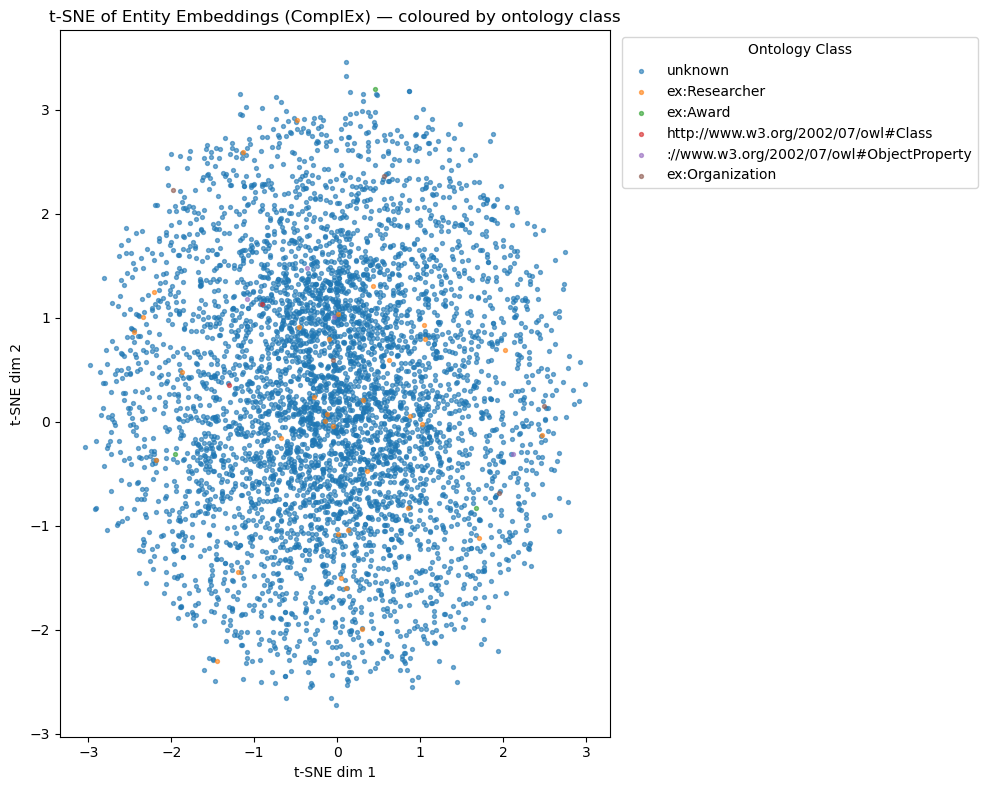

In [25]:
df_tsne = pd.DataFrame({
    'x': coords[:, 0],
    'y': coords[:, 1],
    'type': [t if t in top_types else 'other' for t in labels_sample]
})

palette = sns.color_palette('tab10', n_colors=len(df_tsne.type.unique()))

fig, ax = plt.subplots(figsize=(10, 8))
for i, typ in enumerate(df_tsne.type.unique()):
    sub = df_tsne[df_tsne.type == typ]
    ax.scatter(sub.x, sub.y, s=8, alpha=0.6, label=typ, color=palette[i])

ax.legend(title='Ontology Class', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title('t-SNE of Entity Embeddings (ComplEx) — coloured by ontology class')
ax.set_xlabel('t-SNE dim 1');  ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'tsne_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ── 6.3 Relation Behaviour Analysis ──────────────────────────────────────────
# Symmetry: ||v(r) + v(r')||₂ should ≈ 0 for inverse pair (r, r')
# Known inverse candidates in our KB:
#   ex:affiliatedWith  ↔  wdt:P108 (employer)

def rel_vec(rel_uri):
    if rel_uri in tf_train.relation_to_id:
        return rel_emb_real[tf_train.relation_to_id[rel_uri]]
    return None

pairs = [
    ('http://example.org/private#affiliatedWith',
     'http://www.wikidata.org/prop/direct/P108',
     'affiliatedWith ↔ P108(employer)'),
    ('http://www.wikidata.org/prop/direct/P101',
     'http://example.org/private#fieldOfStudy',
     'wdt:P101 ↔ ex:fieldOfStudy'),
]

print('=== Relation Inversion Coherence (lower ‖r + r′‖ = more inverse-like) ===')
for r1_uri, r2_uri, label in pairs:
    v1, v2 = rel_vec(r1_uri), rel_vec(r2_uri)
    if v1 is None or v2 is None:
        print(f'  {label}: one or both URIs not in vocabulary')
        continue
    norm_sum  = np.linalg.norm(v1 + v2)
    cos       = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-9)
    print(f'  {label}')
    print(f'    ‖r₁ + r₂‖ = {norm_sum:.4f}   cos(r₁, r₂) = {cos:.4f}')
    print(f'    → Inverse structure: {"YES" if norm_sum < 1.0 else "WEAK"}')

=== Relation Inversion Coherence (lower ‖r + r′‖ = more inverse-like) ===
  affiliatedWith ↔ P108(employer)
    ‖r₁ + r₂‖ = 8.6794   cos(r₁, r₂) = 0.4387
    → Inverse structure: WEAK
  wdt:P101 ↔ ex:fieldOfStudy: one or both URIs not in vocabulary


---
### Part 2.8 · SWRL Rule vs. Embedding Vector Arithmetic

In [27]:
# Rule: Researcher(?p) ∧ affiliatedWith(?p, ?org) ∧ wonAward(?p, ex:Nobel_Prize_in_Physics)
#       → PhysicsNobelist(?p)
#
# Embedding analogy:
#   vector(affiliatedWith) + vector(wonAward) ≈ vector(Nobel_Prize_in_Physics) ?

R_AFF   = 'http://example.org/private#affiliatedWith'
R_AWARD = 'http://example.org/private#wonAward'
E_NOBEL = 'http://example.org/private#Nobel_Prize_in_Physics'

missing = []
for uri, label in [(R_AFF,'affiliatedWith'),(R_AWARD,'wonAward'),(E_NOBEL,'Nobel_Prize_in_Physics')]:
    if uri not in {**tf_train.relation_to_id, **tf_train.entity_to_id}:
        missing.append(label)

if missing:
    print(f'Missing from vocabulary: {missing}')
    print('Skipping vector arithmetic (vocabulary too small for this exact check).')
else:
    v_aff   = rel_emb_real[tf_train.relation_to_id[R_AFF]]
    v_award = rel_emb_real[tf_train.relation_to_id[R_AWARD]]
    v_nobel = ent_emb_real[tf_train.entity_to_id[E_NOBEL]]

    composed = v_aff + v_award
    sim = np.dot(composed, v_nobel) / (
          np.linalg.norm(composed) * np.linalg.norm(v_nobel) + 1e-9)

    print('=== Rule vs. Embedding Analogy ===')
    print(f'  SWRL rule : Researcher ∧ affiliatedWith ∧ wonAward → Nobel physicist')
    print(f'  Embedding : vec(affiliatedWith) + vec(wonAward)')
    print(f'  cos( composed, Nobel_Prize_in_Physics ) = {sim:.4f}')
    print(f'  → Analogy holds: {"YES" if sim > 0.5 else "PARTIAL/WEAK"}')

    # For each researcher, check if they won a Physics Nobel
    # by computing: entity_vec + vec(wonAward) closest to Nobel entity
    print('\n  Researcher → Physics Nobel prediction via embedding:')
    for res_uri in [
        'http://example.org/private#Albert_Einstein',
        'http://example.org/private#Marie_Curie',
        'http://example.org/private#Alan_Turing',
    ]:
        if res_uri not in tf_train.entity_to_id:
            continue
        v_res  = ent_emb_real[tf_train.entity_to_id[res_uri]]
        query  = v_res + v_award
        scores = ent_emb_real @ query
        top1   = id2ent[scores.argmax()]
        print(f'    {short(res_uri):25s} → predicted object: {short(top1)}')

=== Rule vs. Embedding Analogy ===
  SWRL rule : Researcher ∧ affiliatedWith ∧ wonAward → Nobel physicist
  Embedding : vec(affiliatedWith) + vec(wonAward)
  cos( composed, Nobel_Prize_in_Physics ) = 0.0658
  → Analogy holds: PARTIAL/WEAK

  Researcher → Physics Nobel prediction via embedding:
    ex:Albert_Einstein        → predicted object: ex:Albert_Einstein
    ex:Marie_Curie            → predicted object: ex:Marie_Curie


---
### Summary Table

In [28]:
print('\n' + '='*70)
print('FINAL EVALUATION TABLE (Filtered Metrics)')
print('='*70)
display_cols = ['MRR', 'H@1', 'H@3', 'H@10']
display_df = df_metrics[display_cols].copy()
display_df.columns = ['MRR', 'Hits@1', 'Hits@3', 'Hits@10']
print(display_df.to_string(float_format='{:.4f}'.format))
print('='*70)


FINAL EVALUATION TABLE (Filtered Metrics)
           MRR  Hits@1  Hits@3  Hits@10
Model                                  
TransE  0.1526  0.0437  0.2044   0.3498
ComplEx 0.0441  0.0169  0.0407   0.0940
